In [64]:
# TO CHECK THE UNIQUE VALUES IN EACH COLUMN

import pandas as pd
import glob

file_path = glob.glob(r'Sentence Memorability\\NewLogsAnonymized\\*.log')

df_master = pd.DataFrame()

for file in file_path:
    df = pd.read_csv(file)
    df_master = pd.concat([df_master, df], ignore_index=True)

to_rem = ["participant_ID", "Timestamp"]
for column in df_master.columns:
    if column in to_rem:
        continue
    print(f"Column {column} has {df_master[column].unique()} unique values.")

Column Event has ['Practice Sentence shown' 'Practice IR pressed' 'Practice Missed'
 'Practice WR pressed' 'Sentence shown' 'gap_time'
 'Validation Wrong IR pressed' 'IR pressed' 'WR pressed'
 'Validation IR pressed' 'Rest Phase started' 'Validation Missed'] unique values.
Column Stimulus has ['HH_112_A' 'HL_16_A' 'HH_116_A' 'HL_62_A' 'HH_103_A' 'HL_64_A' 'HL_37_A'
 'HL_74_A' 'HH_112_P' 'HH_116_P' 'HL_5_A' 'HL_4_A' 'HL_65_A' 'HH_100_A'
 'HL_68_A' 'HL_31_A' 'HH_127_A' 'HH_127_P' 'HH_135_A' 'HL_18_A' 'HL_91_A'
 'HL_93_A' 'HL_97_A' 'HH_135_P' 'HH_108_A' 'HH_131_A' 'HH_136_A' 'HL_55_A'
 'HL_56_A' 'HH_131_P' 'HH_100_P' 'HL_69_A' 'HL_86_A' 'HL_61_A' 'HL_102_A'
 'HF_29_A' nan 'HF_9_A' 'HF_24_A' 'HF_1_A' 'HF_7_A' 'HF_28_A' 'HF_11_A'
 'HF_2_A' 'HF_4_A' 'HF_32_A' 'HF_31_A' 'HF_5_A' 'HF_22_A' 'HF_30_A'
 'LVL_148_P' 'HF_19_A' 'HF_12_A' 'HVL_121_P' 'HH_172_A' 'LVL_110_A'
 'HF_13_A' 'LVL_109_P' 'LVL_148_A' 'LVH_105_A' 'HF_25_A' 'HF_17_A'
 'HH_172_P' 'HF_8_A' 'HF_6_A' 'HF_20_A' 'HF_21_A' 'LVH_107_P' 

In [65]:
import pandas as pd
from pathlib import Path
import os

input_dir = r"Sentence Memorability/NewLogsAnonymized"
output_dir = r"Sentence Memorability/ProcessedData"
input_path = Path(input_dir)
output_path = Path(output_dir)
output_path.mkdir(parents=True, exist_ok=True)

for filepath in input_path.glob("*.log"):
    part_id = filepath.stem 
    
    try:
        df = pd.read_csv(filepath)
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        continue

    df['Block'] = (df['Event'] == 'Rest Phase started').shift(fill_value=False).cumsum() + 1
    
    df = df[~df['Event'].str.contains('Practice', case=False, na=False)]
    df = df[~df['Event'].isin(['gap_time', 'Rest Phase started'])]
    df = df.reset_index(drop=True)

    df['Trial_ID'] = (df['Event'] == 'Sentence shown').cumsum()
    
    df = df[df['Trial_ID'] > 0]

    flattened_trials = []

    for trial_id, group in df.groupby('Trial_ID'):
        block_num = group['Block'].iloc[0]
        
        trial_data = {
            'Participant_ID': part_id,
            'Block': block_num,
            'Trial_ID': trial_id
        }

        sentence_row = group[group['Event'] == 'Sentence shown']
        if not sentence_row.empty:
            trial_data['Stimulus'] = sentence_row.iloc[0].get('Stimulus', pd.NA)
            trial_data['isTarget'] = sentence_row.iloc[0].get('isTarget', pd.NA)
            trial_data['isValidation'] = sentence_row.iloc[0].get('isValidation', pd.NA)
            trial_data['isRepeat'] = sentence_row.iloc[0].get('isRepeat', pd.NA)

        ir_row = group[group['Event'].str.contains('IR|Validation Missed', regex=True, na=False)]
        if not ir_row.empty:
            trial_data['IR_Event'] = ir_row.iloc[-1]['Event']
            trial_data['Accuracy_IR'] = ir_row.iloc[-1].get('Accuracy IR', pd.NA)
            trial_data['Reaction_time_IR'] = ir_row.iloc[-1].get('Reaction_time_IR', pd.NA)

        wr_row = group[group['Event'].str.contains('WR', na=False)]
        if not wr_row.empty:
            trial_data['WR_Event'] = wr_row.iloc[-1]['Event']
            trial_data['Accuracy_WR'] = wr_row.iloc[-1].get('Accuracy WR', pd.NA)
            trial_data['Reaction_time_WR'] = wr_row.iloc[-1].get('Reaction_time_WR', pd.NA)

        flattened_trials.append(trial_data)

    if flattened_trials:
        participant_df = pd.DataFrame(flattened_trials)
        
        for block_num, block_df in participant_df.groupby('Block'):
            
            val_df = block_df[block_df['isValidation'] == True]
            
            is_valid = True
            
            if not val_df.empty:
                correct_val = (val_df['Accuracy_IR'] == 1).sum()
                
                missed_val = val_df['IR_Event'].str.contains('Missed', case=False, na=False).sum()
                
                wrong_val = len(val_df) - correct_val - missed_val
                
                is_valid = correct_val > ((wrong_val / 2) + missed_val)

            if is_valid:
                output_filename = f"{part_id}_block{block_num}.csv"
                output_filepath = output_path / output_filename
                block_df.to_csv(output_filepath, index=False)
            else:
                print(f"Removed invalid block: {part_id}_block{block_num}.csv (Failed attention check)")

Removed invalid block: 299_block2.csv (Failed attention check)
Removed invalid block: 299_block3.csv (Failed attention check)


In [66]:
# COMBINE ALL PROCESSED CSV FILES INTO A MASTER DATASET

import pandas as pd
import glob
from pathlib import Path

df_master = pd.DataFrame()
for file in Path("Sentence Memorability/ProcessedData").glob("*.csv"):
    df = pd.read_csv(file)
    df_master = pd.concat([df_master, df], ignore_index=True)
    
df_master.to_csv("master_dataset.csv", index=False)
    

In [67]:
# CREATE STIMULUS-LEVEL SUMMARY DATASET WITH CALCULATED METRICS

import pandas as pd
import numpy as np

df_master = pd.read_csv("master_dataset.csv")
df_master = df_master[(df_master['isValidation'] != True) & (df_master['isTarget'] == True)]


df_master['Accuracy_IR'] = pd.to_numeric(df_master['Accuracy_IR'], errors='coerce')
df_master['Accuracy_WR'] = pd.to_numeric(df_master['Accuracy_WR'], errors='coerce')

df_master['isRepeat'] = df_master['isRepeat'].fillna(False)

df_master['Is_Correct_IR_Hit'] = ((df_master['isRepeat'] == True) & (df_master['Accuracy_IR'] == 1.0))

df_master['Is_Correct_IR_Miss'] = (df_master['isRepeat'] == False) & (df_master['Accuracy_IR'].isna())

df_master['Is_Wrong_IR'] = (df_master['isRepeat'] == False) & (df_master['Accuracy_IR'] == 0.0)

df_master['Is_Missed_IR'] = (df_master['isRepeat'] == True) & (df_master['Accuracy_IR'].isna())

df_master['Is_Correct_WR'] = df_master['Accuracy_WR'] == 1.0
df_master['Is_Wrong_WR'] = df_master['Accuracy_WR'] == 0.0

df_master['WR_Hit'] = (df_master['isRepeat'] == True) & (df_master['Accuracy_WR'] == 1.0)
df_master['WR_Miss'] = (df_master['isRepeat'] == True) & (df_master['Accuracy_WR'] == 0.0)
df_master['WR_CR'] = (df_master['isRepeat'] == False) & (df_master['Accuracy_WR'] == 1.0)
df_master['WR_FA'] = (df_master['isRepeat'] == False) & (df_master['Accuracy_WR'] == 0.0)

df_master['Num_WR'] = df_master['IR_Event'].notna().astype(int)

stimulus_summary = df_master.groupby('Stimulus').agg(
    Num_Participants=('Participant_ID', 'nunique'),
    Num_Correct_IR_Hit=('Is_Correct_IR_Hit', 'sum'),
    Num_Correct_IR_Miss=('Is_Correct_IR_Miss', 'sum'),
    Num_Wrong_IR=('Is_Wrong_IR', 'sum'),
    Num_Missed_IR=('Is_Missed_IR', 'sum'),
    Num_Correct_WR=('Is_Correct_WR', 'sum'),
    Num_Wrong_WR=('Is_Wrong_WR', 'sum'),
    Num_WR=('Num_WR', 'sum'),
    Num_WR_Hit=('WR_Hit', 'sum'),
    Num_WR_Miss=('WR_Miss', 'sum'),
    Num_WR_CR=('WR_CR', 'sum'),
    Num_WR_FA=('WR_FA', 'sum')
).reset_index()

stimulus_summary['sentence_type'] = stimulus_summary['Stimulus'].str.split('_').str[0].str.replace('V', '')
stimulus_summary['voice'] = stimulus_summary['Stimulus'].str.split('_').str[-1]
cols = ['Stimulus', 'sentence_type', 'voice'] + [c for c in stimulus_summary.columns if c not in ['Stimulus', 'sentence_type', 'voice', 'voice_code']]
stimulus_summary = stimulus_summary[cols]


df_master = df_master.drop(columns=['Is_Correct_IR_Hit', 'Is_Correct_IR_Miss', 'Is_Wrong_IR', 'Is_Missed_IR', 'Is_Correct_WR', 'Is_Wrong_WR', 'Num_WR'])


stimulus_summary["IR_Accuracy"] = (stimulus_summary['Num_Correct_IR_Hit'] + stimulus_summary['Num_Correct_IR_Miss']) / (stimulus_summary['Num_Correct_IR_Hit'] + stimulus_summary['Num_Correct_IR_Miss'] + stimulus_summary['Num_Wrong_IR'] + stimulus_summary['Num_Missed_IR'])
stimulus_summary["WR_Accuracy"] = stimulus_summary['Num_Correct_WR'] / stimulus_summary['Num_WR']

stimulus_summary['CM_IR'] = (stimulus_summary['Num_Correct_IR_Hit'] / (stimulus_summary['Num_Correct_IR_Hit'] + stimulus_summary['Num_Missed_IR'])) - (stimulus_summary['Num_Wrong_IR'] / (stimulus_summary['Num_Wrong_IR'] + stimulus_summary['Num_Correct_IR_Miss']))

stimulus_summary['WR_Hit_Rate'] = np.where(
    (stimulus_summary['Num_WR_Hit'] + stimulus_summary['Num_WR_Miss']) > 0,
    stimulus_summary['Num_WR_Hit'] / (stimulus_summary['Num_WR_Hit'] + stimulus_summary['Num_WR_Miss']),
    np.nan
)


stimulus_summary['WR_FA_Rate'] = np.where(
    (stimulus_summary['Num_WR_FA'] + stimulus_summary['Num_WR_CR']) > 0,
    stimulus_summary['Num_WR_FA'] / (stimulus_summary['Num_WR_FA'] + stimulus_summary['Num_WR_CR']),
    np.nan
)

stimulus_summary['CM_WR'] = stimulus_summary['WR_Hit_Rate'] - stimulus_summary['WR_FA_Rate']
df_master = df_master.drop(columns=['WR_Hit', 'WR_Miss', 'WR_CR', 'WR_FA'])
stimulus_summary = stimulus_summary.drop(columns=['WR_Hit_Rate', 'WR_FA_Rate'])

print(stimulus_summary.head())
stimulus_summary.to_csv("stimulus_summary.csv", index=False)

   Stimulus sentence_type voice  Num_Participants  Num_Correct_IR_Hit  \
0  HH_137_A            HH     A                49                  26   
1  HH_137_P            HH     P                54                  32   
2  HH_138_A            HH     A                27                  17   
3  HH_138_P            HH     P                24                  12   
4  HH_139_A            HH     A                36                  19   

   Num_Correct_IR_Miss  Num_Wrong_IR  Num_Missed_IR  Num_Correct_WR  \
0                   30             1              6              19   
1                   34             3              4              27   
2                   17             0              3              13   
3                   17             0              2               8   
4                   26             2              3              19   

   Num_Wrong_WR  Num_WR  Num_WR_Hit  Num_WR_Miss  Num_WR_CR  Num_WR_FA  \
0             8      27          18            8          1 

C:\Users\ritvi\AppData\Local\Temp\ipykernel_27416\1593553856.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_master['isRepeat'] = df_master['isRepeat'].fillna(False)


In [68]:
# DESCRIPTIVE STATISTICS FOR STIMULUS-LEVEL METRICS
import pandas as pd

df = pd.read_csv("stimulus_summary.csv")
target_metrics = ['IR_Accuracy', 'WR_Accuracy', 'CM_IR', 'CM_WR']

print("=== 1. OVERALL DESCRIPTIVE STATISTICS ===")
overall_stats = df[target_metrics].describe().round(3)

overall_stats.loc['var'] = df[target_metrics].var().round(3)
print(overall_stats)
print("\n" + "="*80 + "\n")

print("=== 2. STATISTICS BY SENTENCE TYPE (Word Memorability) ===")
type_stats = df.groupby('sentence_type')[target_metrics].describe().round(3)
print(type_stats.to_string())
print("\n" + "="*80 + "\n")

print("=== 3. STATISTICS BY VOICE (Active vs. Passive) ===")
voice_stats = df.groupby('voice')[target_metrics].describe().round(3)
print(voice_stats.to_string())
print("\n" + "="*80 + "\n")

=== 1. OVERALL DESCRIPTIVE STATISTICS ===
       IR_Accuracy  WR_Accuracy    CM_IR    CM_WR
count      392.000      392.000  392.000  136.000
mean         0.897        0.744    0.795    0.262
std          0.067        0.142    0.133    0.474
min          0.607        0.167    0.271   -0.667
25%          0.857        0.664    0.715   -0.191
50%          0.906        0.750    0.812    0.206
75%          0.943        0.843    0.889    0.718
max          1.000        1.000    1.000    1.000
var          0.004        0.020    0.018    0.224


=== 2. STATISTICS BY SENTENCE TYPE (Word Memorability) ===
              IR_Accuracy                                                WR_Accuracy                                                CM_IR                                                CM_WR                                                 
                    count   mean    std    min    25%    50%    75%  max       count   mean    std    min    25%    50%    75%  max count   mean    std    mi

In [69]:
import pandas as pd

df_master = pd.read_csv("master_dataset.csv")

df_valid = df_master[df_master['isTarget'].astype(str).str.lower() == 'true'].copy()

df_valid['sentence_type'] = df_valid['Stimulus'].str.split('_').str[0].str.replace('V', '')
df_valid['voice'] = df_valid['Stimulus'].str.split('_').str[-1]

print("=== 1. SENTENCES SEEN BY EACH PARTICIPANT ===")
part_type_counts = df_valid.groupby(['Participant_ID', 'sentence_type'])['Stimulus'].nunique().unstack(fill_value=0)

print("--- By Sentence Type ---")
for col in part_type_counts.columns:
    distribution = part_type_counts[col].value_counts().sort_index(ascending=False)
    print(f"\nType '{col}':")
    for count, num_people in distribution.items():
        print(f"  -> {num_people} participants saw exactly {count} unique sentences")

part_voice_counts = df_valid.groupby(['Participant_ID', 'voice'])['Stimulus'].nunique().unstack(fill_value=0)

print("\n--- By Voice ---")
for col in part_voice_counts.columns:
    distribution = part_voice_counts[col].value_counts().sort_index(ascending=False)
    print(f"\nVoice '{col}':")
    for count, num_people in distribution.items():
        print(f"  -> {num_people} participants saw exactly {count} unique sentences")

print("\n" + "="*50 + "\n")

print("=== 2. TOTAL UNIQUE SENTENCES POOL ===")
print("Confirming the overall inventory of sentences across the whole experiment.\n")

unique_sentences = df_valid.groupby(['sentence_type', 'voice'])['Stimulus'].nunique().unstack(fill_value=0)
print(unique_sentences)

=== 1. SENTENCES SEEN BY EACH PARTICIPANT ===
--- By Sentence Type ---

Type 'HH':
  -> 113 participants saw exactly 18 unique sentences
  -> 1 participants saw exactly 6 unique sentences

Type 'HL':
  -> 113 participants saw exactly 18 unique sentences
  -> 1 participants saw exactly 6 unique sentences

Type 'LH':
  -> 113 participants saw exactly 18 unique sentences
  -> 1 participants saw exactly 6 unique sentences

Type 'LL':
  -> 113 participants saw exactly 18 unique sentences
  -> 1 participants saw exactly 6 unique sentences

--- By Voice ---

Voice 'A':
  -> 113 participants saw exactly 36 unique sentences
  -> 1 participants saw exactly 12 unique sentences

Voice 'P':
  -> 113 participants saw exactly 36 unique sentences
  -> 1 participants saw exactly 12 unique sentences


=== 2. TOTAL UNIQUE SENTENCES POOL ===
Confirming the overall inventory of sentences across the whole experiment.

voice           A   P
sentence_type        
HH             49  49
HL             49  49
LH

=== PARTICIPANT COUNT PER SENTENCE ===
 Stimulus  Num_Participants
HVL_161_P                 7
HVL_129_P                 8
LVH_138_A                 8
LVH_172_A                 8
LVH_182_P                 8
 HH_186_A                 9
HVL_155_A                 9
HVL_161_A                 9
LVH_166_A                 9
LVH_166_P                 9
LVH_177_A                 9
LVH_177_P                 9
 HH_178_A                10
 HH_185_A                10
HVL_129_A                10
HVL_152_A                10
LVL_147_P                10
 HH_160_P                11
 HH_182_P                11
HVL_153_A                11
HVL_155_P                11
HVL_158_P                11
LVH_149_P                11
LVH_171_P                11
LVL_139_A                11
LVL_143_P                11
 HH_164_P                12
 HH_188_A                12
HVL_141_P                12
HVL_143_P                12
HVL_150_A                12
LVH_170_P                12
LVH_178_P                12
LVL_138_A

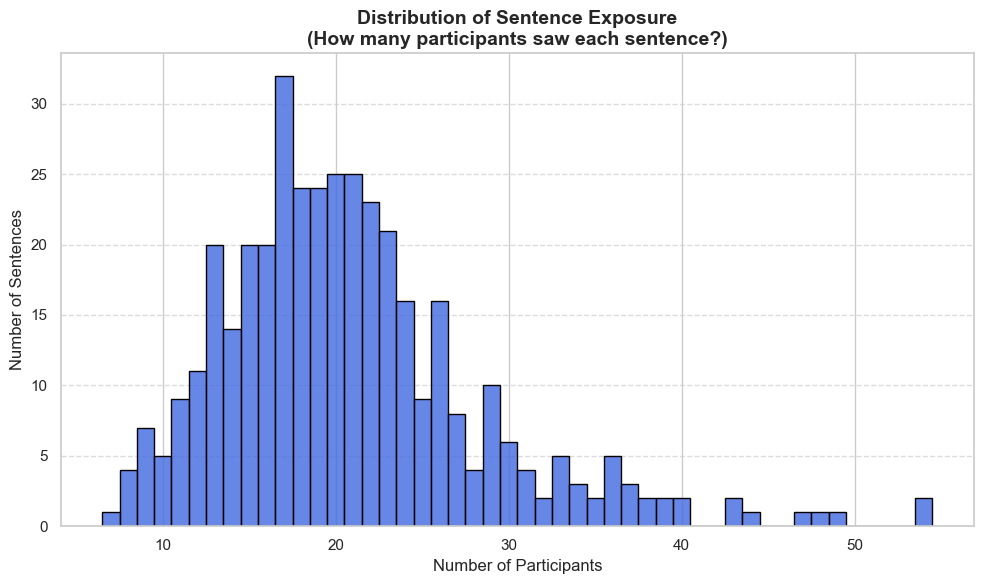

In [70]:
import pandas as pd

df_valid = df_master[df_master['isTarget'].astype(str).str.lower() == 'true']

print("=== PARTICIPANT COUNT PER SENTENCE ===")

sentence_exposure = df_valid.groupby('Stimulus')['Participant_ID'].nunique().reset_index(name='Num_Participants')

sentence_exposure = sentence_exposure.sort_values(by=['Num_Participants', 'Stimulus'])

print(sentence_exposure.to_string(index=False))

import matplotlib.pyplot as plt
import seaborn as sns


sentence_exposure = df_valid.groupby('Stimulus')['Participant_ID'].nunique().reset_index(name='Num_Participants')


plt.figure(figsize=(10, 6))

sns.histplot(
    data=sentence_exposure, 
    x='Num_Participants', 
    discrete=True, 
    color='royalblue', 
    edgecolor='black',
    alpha=0.8
)

plt.title('Distribution of Sentence Exposure\n(How many participants saw each sentence?)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Participants', fontsize=12)
plt.ylabel('Number of Sentences', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\ritvi\AppData\Local\Temp\ipykernel_27416\1579400411.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentence_type', y=metric, order=type_order, ax=axes1[0, i], palette='Set2')
C:\Users\ritvi\AppData\Local\Temp\ipykernel_27416\1579400411.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='voice', y=metric, ax=axes1[1, i], palette=['#4C72B0', '#55A868'])
C:\Users\ritvi\AppData\Local\Temp\ipykernel_27416\1579400411.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentence_type', y=metric, o

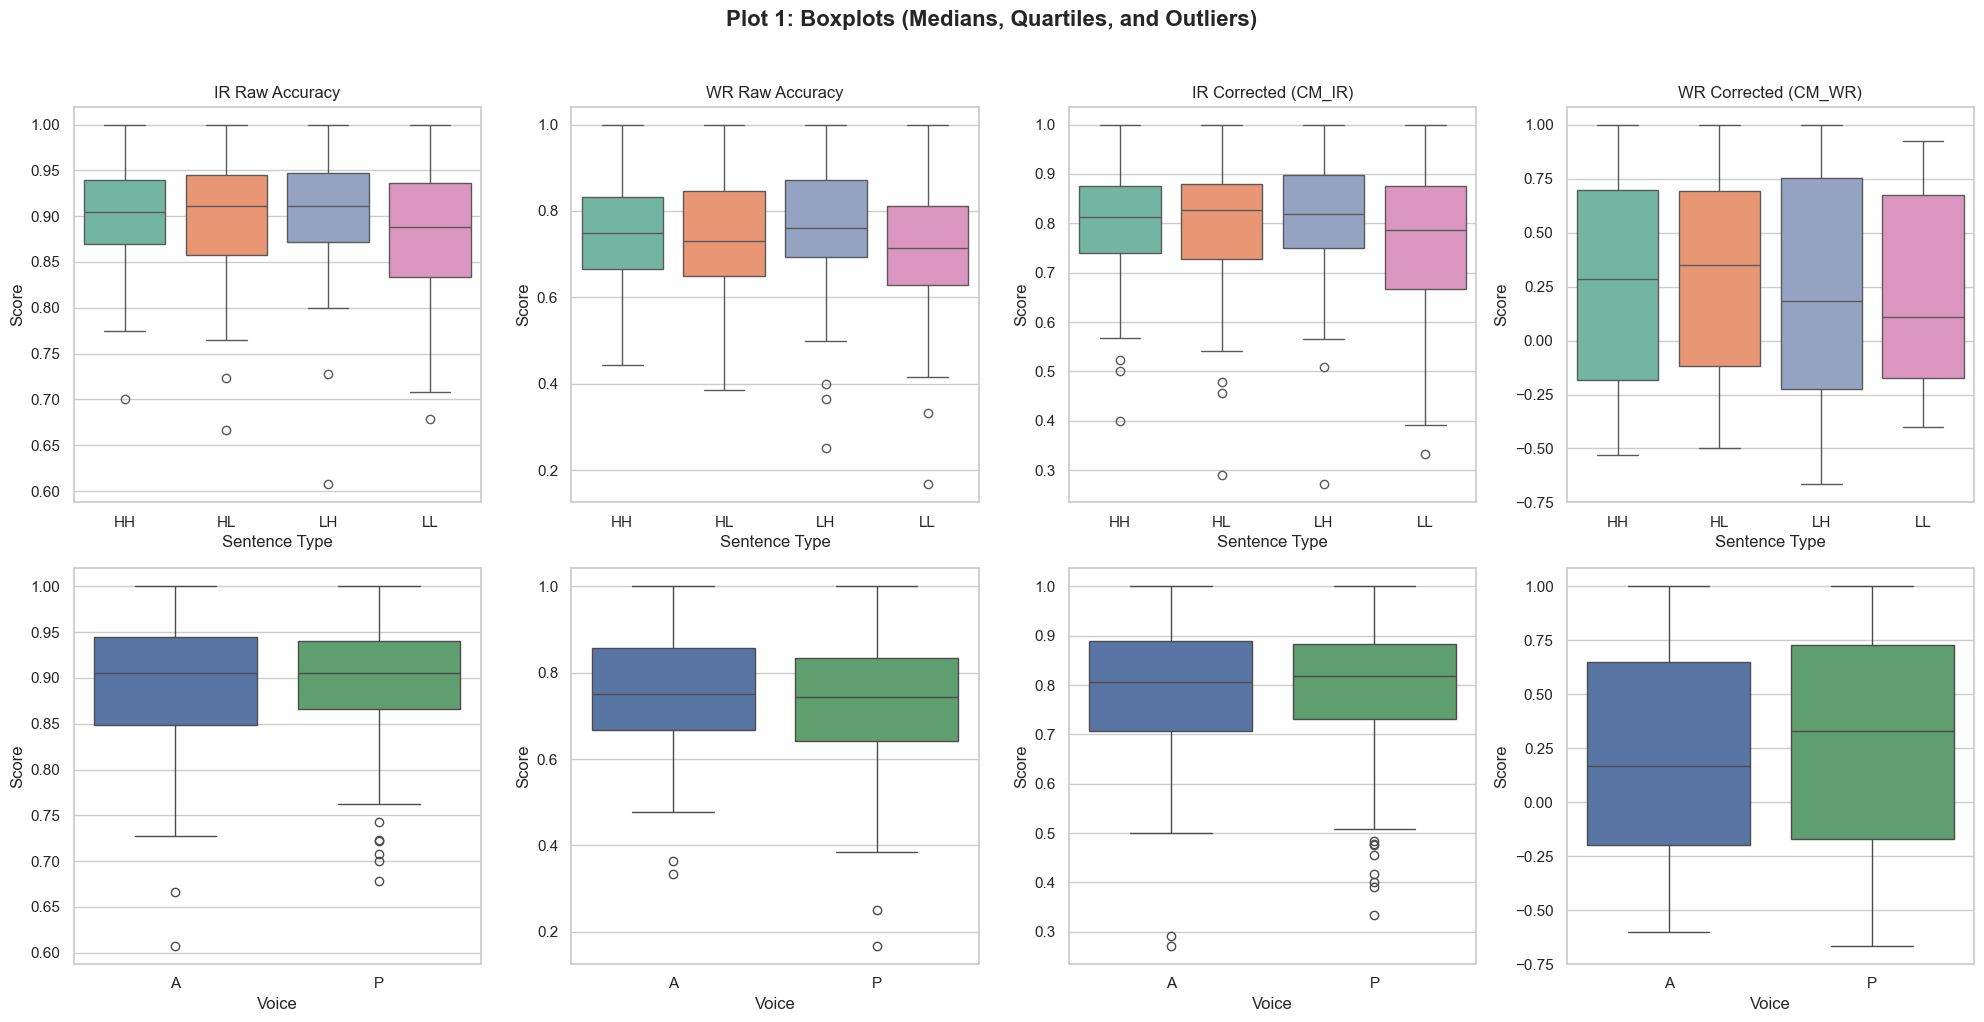

C:\Users\ritvi\AppData\Local\Temp\ipykernel_27416\1579400411.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='sentence_type', y=metric, order=type_order,
C:\Users\ritvi\AppData\Local\Temp\ipykernel_27416\1579400411.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='voice', y=metric,
C:\Users\ritvi\AppData\Local\Temp\ipykernel_27416\1579400411.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='sentence_type', y=metric, order=type_order,
C:\Users\ritvi\AppData\Local\Temp\ipykernel_27416\1579

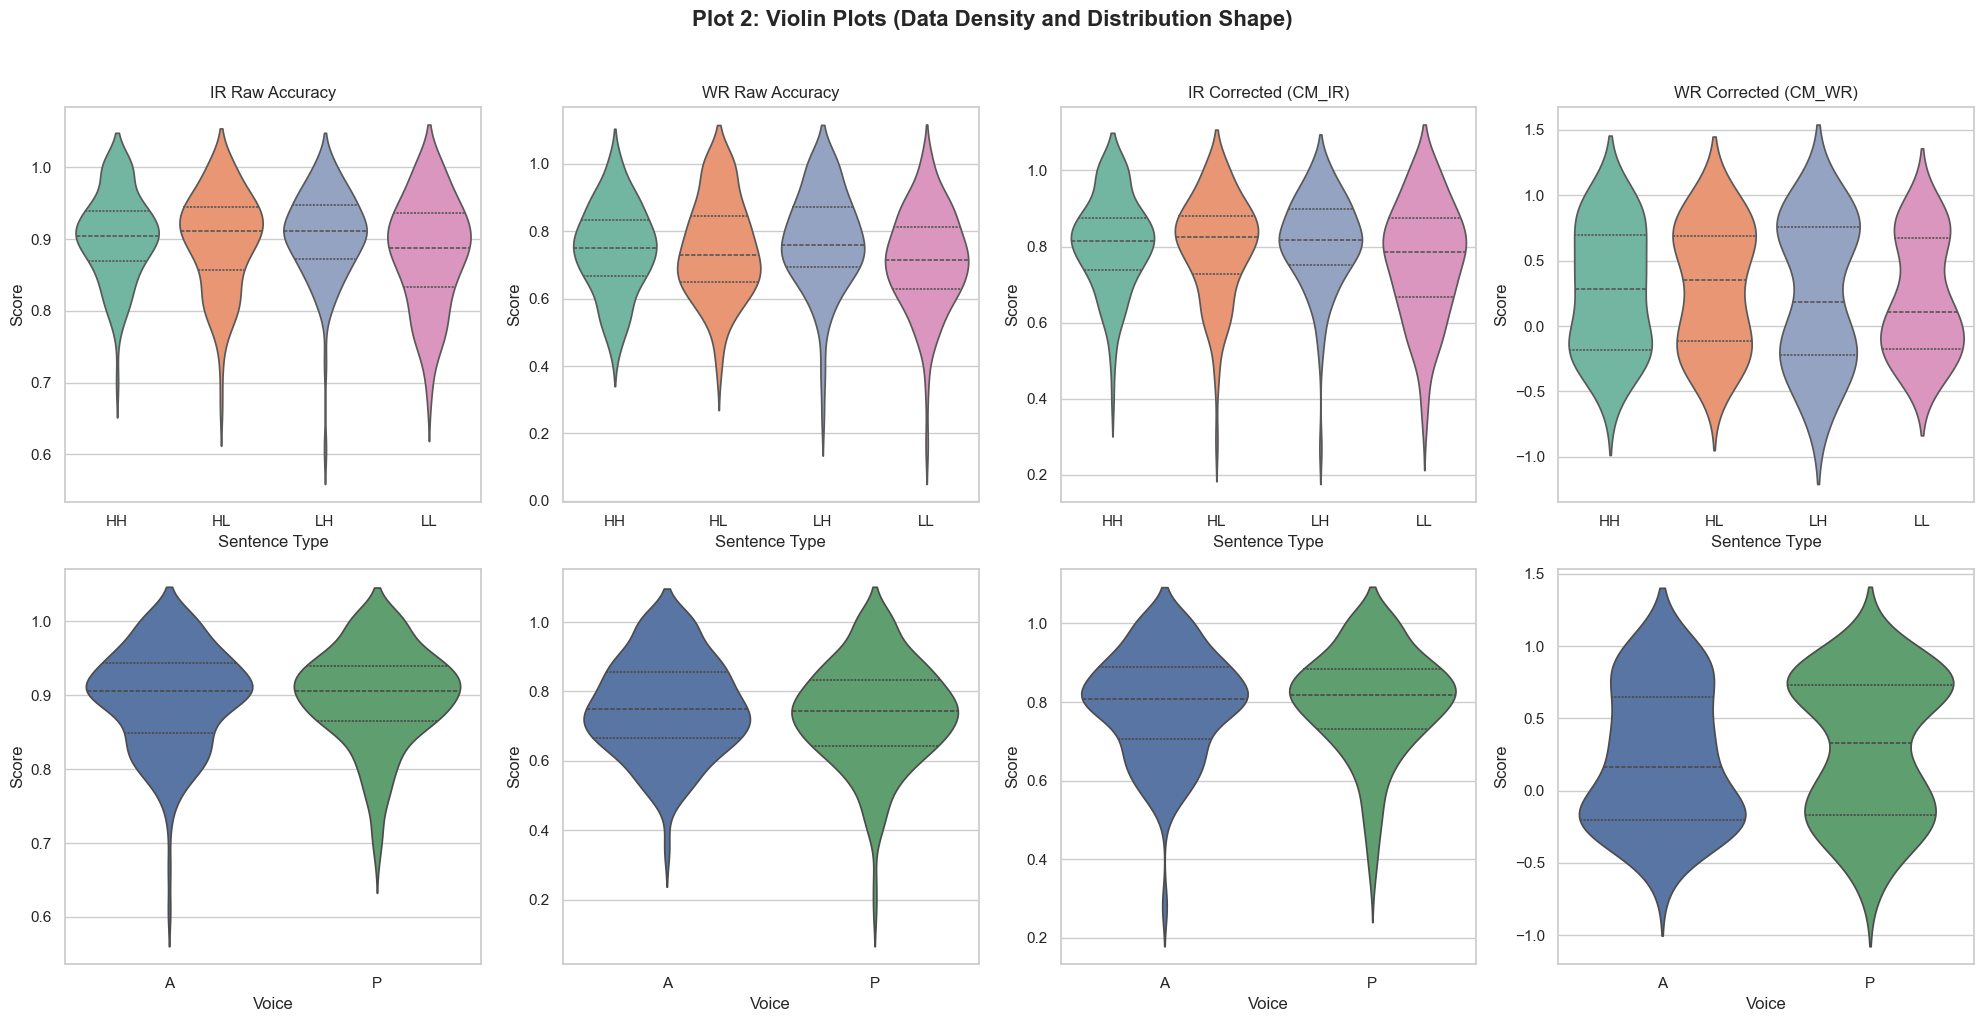

In [71]:
# VISUALIZATION OF STIMULUS-LEVEL METRICS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_path = "stimulus_summary.csv"
df = pd.read_csv(data_path)
sns.set_theme(style="whitegrid")

metrics = ['IR_Accuracy', 'WR_Accuracy', 'CM_IR', 'CM_WR']
metric_titles = ['IR Raw Accuracy', 'WR Raw Accuracy', 'IR Corrected (CM_IR)', 'WR Corrected (CM_WR)']
type_order = ['HH', 'HL', 'LH', 'LL']

fig1, axes1 = plt.subplots(2, 4, figsize=(20, 10))
fig1.suptitle('Plot 1: Boxplots (Medians, Quartiles, and Outliers)', fontsize=16, fontweight='bold', y=1.02)

for i, metric in enumerate(metrics):
    sns.boxplot(data=df, x='sentence_type', y=metric, order=type_order, ax=axes1[0, i], palette='Set2')
    axes1[0, i].set_title(metric_titles[i])
    axes1[0, i].set_xlabel('Sentence Type')
    axes1[0, i].set_ylabel('Score')

    sns.boxplot(data=df, x='voice', y=metric, ax=axes1[1, i], palette=['#4C72B0', '#55A868'])
    axes1[1, i].set_xlabel('Voice')
    axes1[1, i].set_ylabel('Score')

plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(2, 4, figsize=(20, 10))
fig2.suptitle('Plot 2: Violin Plots (Data Density and Distribution Shape)', fontsize=16, fontweight='bold', y=1.02)

for i, metric in enumerate(metrics):
    sns.violinplot(data=df, x='sentence_type', y=metric, order=type_order, 
                    ax=axes2[0, i], palette='Set2', inner='quartile')
    axes2[0, i].set_title(metric_titles[i])
    axes2[0, i].set_xlabel('Sentence Type')
    axes2[0, i].set_ylabel('Score')

    sns.violinplot(data=df, x='voice', y=metric, 
                    ax=axes2[1, i], palette=['#4C72B0', '#55A868'], inner='quartile')
    axes2[1, i].set_xlabel('Voice')
    axes2[1, i].set_ylabel('Score')

plt.tight_layout()
plt.show()



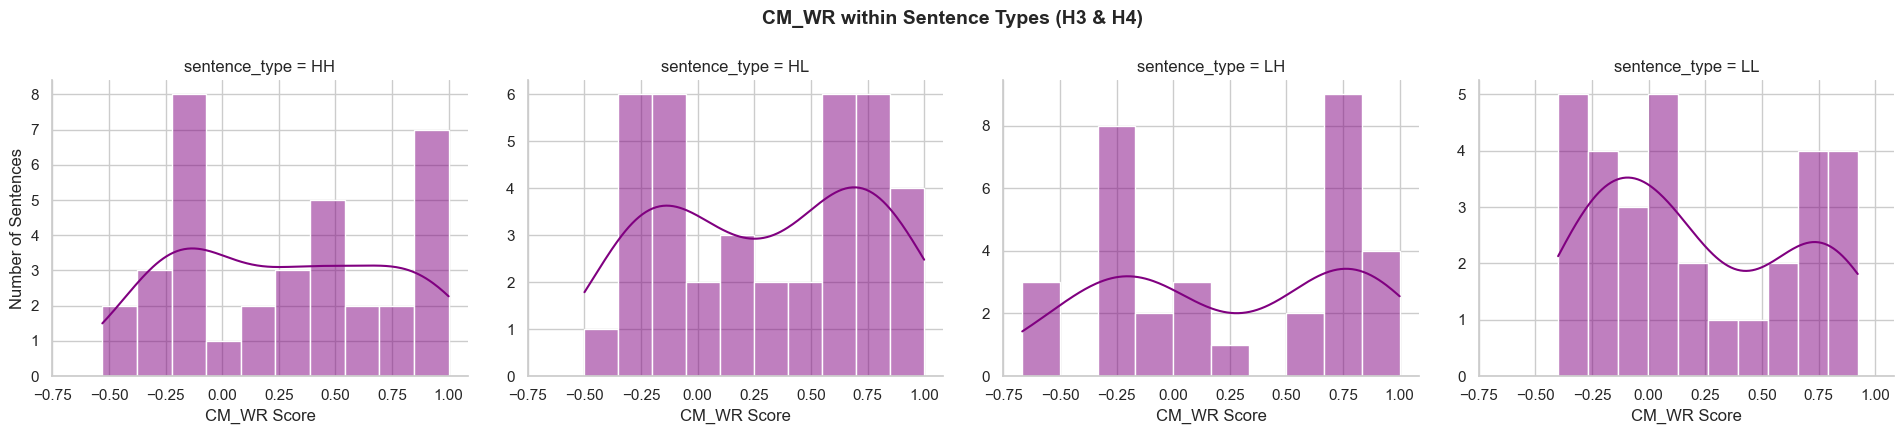

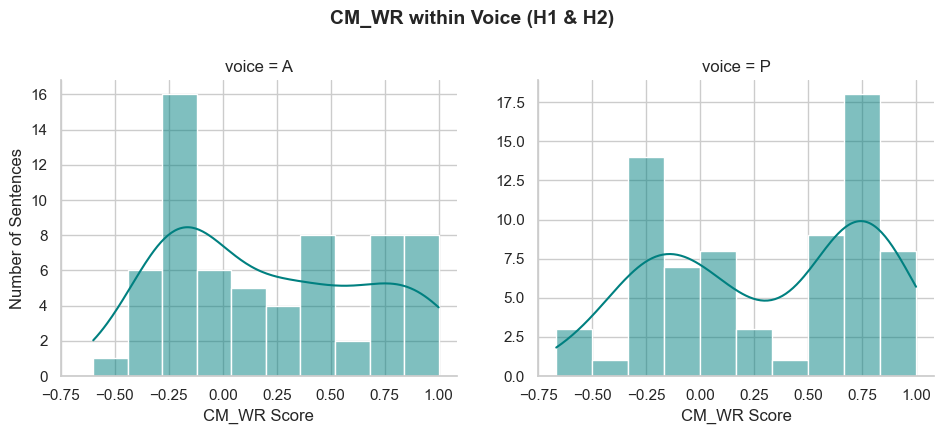

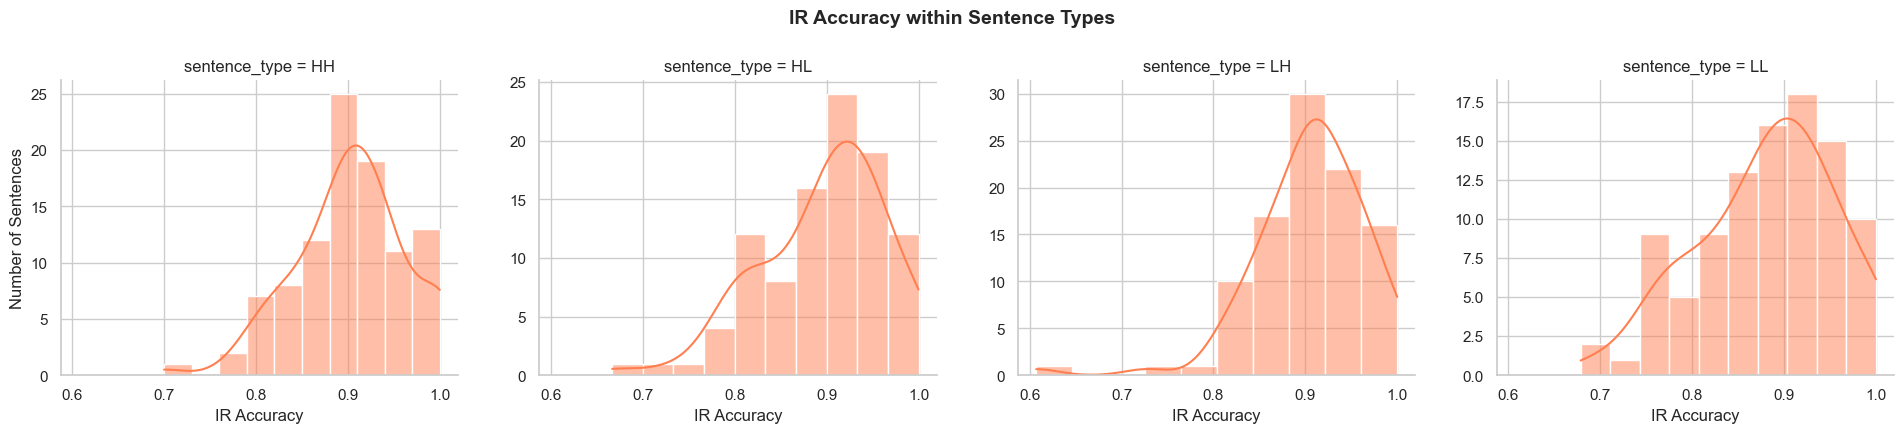

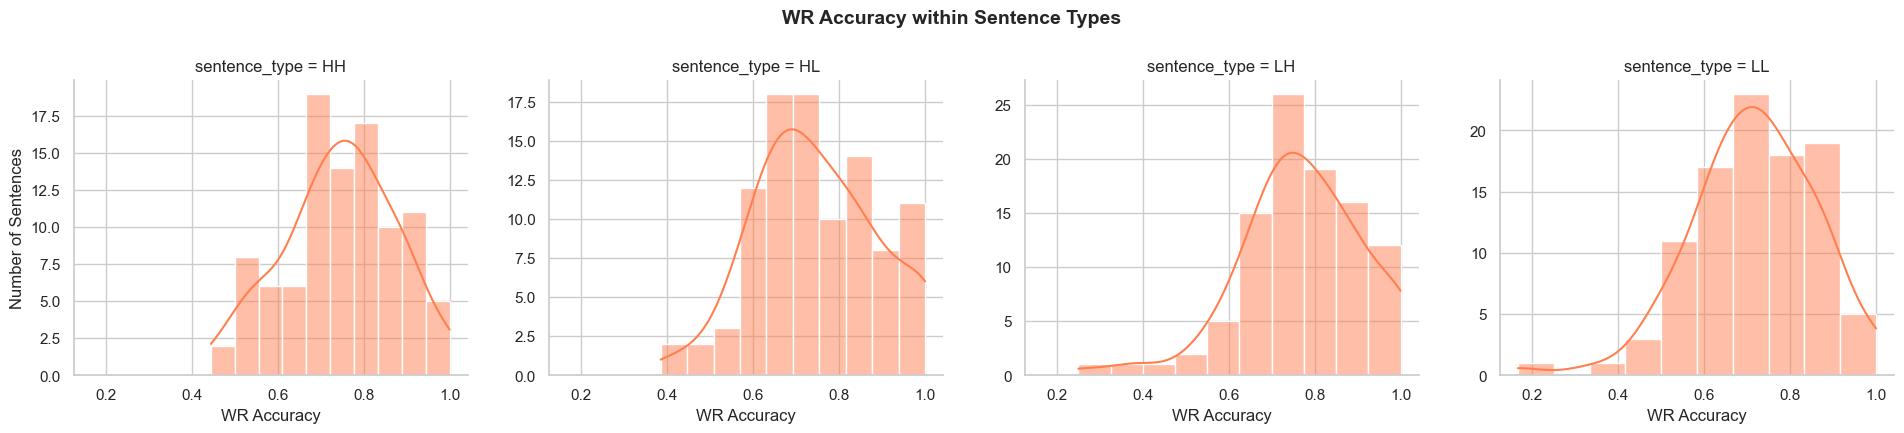

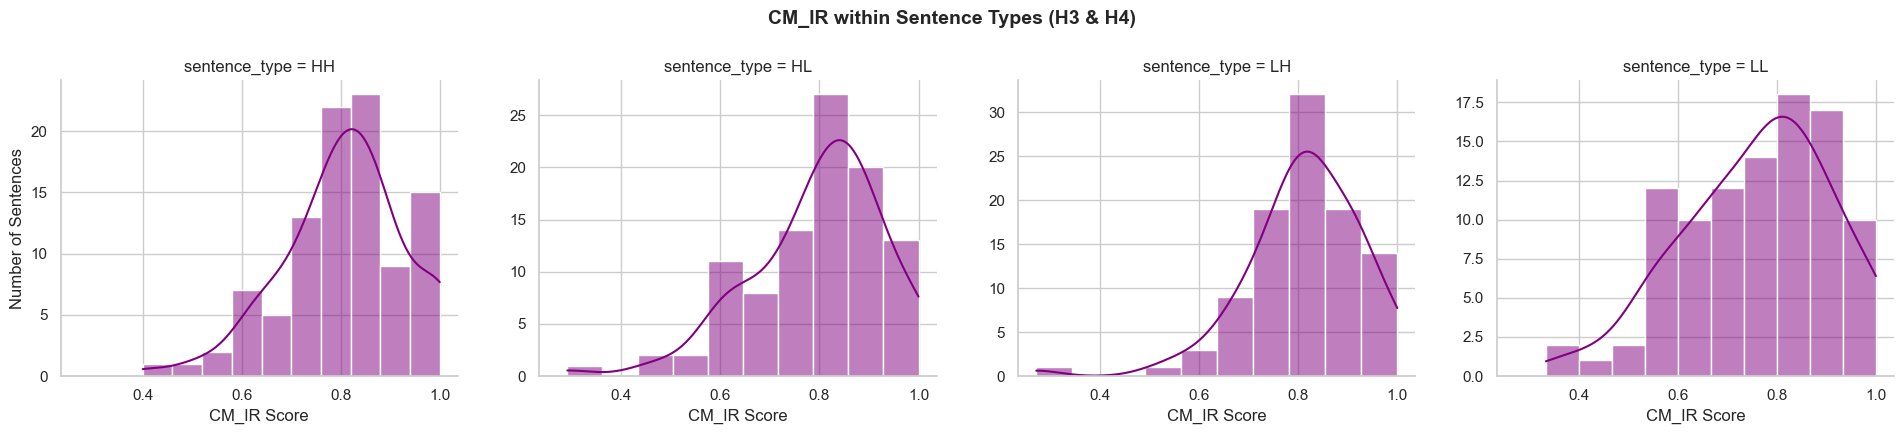

In [72]:
# Normality check for CM_WR and IR_Accuracy across sentence types and voice
    
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_path = "stimulus_summary.csv"
df = pd.read_csv(data_path)
sns.set_theme(style="whitegrid")

type_order = ['HH', 'HL', 'LH', 'LL']

g1 = sns.FacetGrid(df, col="sentence_type", col_order=type_order, height=4, aspect=1.2, sharey=False)
g1.map_dataframe(sns.histplot, x="CM_WR", kde=True, color='purple', bins=10)
g1.fig.suptitle('CM_WR within Sentence Types (H3 & H4)', y=1.08, fontsize=14, fontweight='bold')
g1.set_axis_labels("CM_WR Score", "Number of Sentences")
plt.show()

g2 = sns.FacetGrid(df, col="voice", height=4, aspect=1.2, sharey=False)
g2.map_dataframe(sns.histplot, x="CM_WR", kde=True, color='teal', bins=10)
g2.fig.suptitle('CM_WR within Voice (H1 & H2)', y=1.08, fontsize=14, fontweight='bold')
g2.set_axis_labels("CM_WR Score", "Number of Sentences")
plt.show()

g3 = sns.FacetGrid(df, col="sentence_type", col_order=type_order, height=4, aspect=1.2, sharey=False)
g3.map_dataframe(sns.histplot, x="IR_Accuracy", kde=True, color='coral', bins=10)
g3.fig.suptitle('IR Accuracy within Sentence Types', y=1.08, fontsize=14, fontweight='bold')
g3.set_axis_labels("IR Accuracy", "Number of Sentences")
plt.show()

g4= sns.FacetGrid(df, col="sentence_type", col_order=type_order, height=4, aspect=1.2, sharey=False)
g4.map_dataframe(sns.histplot, x="WR_Accuracy", kde=True, color='coral', bins=10)
g4.fig.suptitle('WR Accuracy within Sentence Types', y=1.08, fontsize=14, fontweight='bold')
g4.set_axis_labels("WR Accuracy", "Number of Sentences")
plt.show()

g5 = sns.FacetGrid(df, col="sentence_type", col_order=type_order, height=4, aspect=1.2, sharey=False)
g5.map_dataframe(sns.histplot, x="CM_IR", kde=True, color='purple', bins=10)
g5.fig.suptitle('CM_IR within Sentence Types (H3 & H4)', y=1.08, fontsize=14, fontweight='bold')
g5.set_axis_labels("CM_IR Score", "Number of Sentences")
plt.show()



